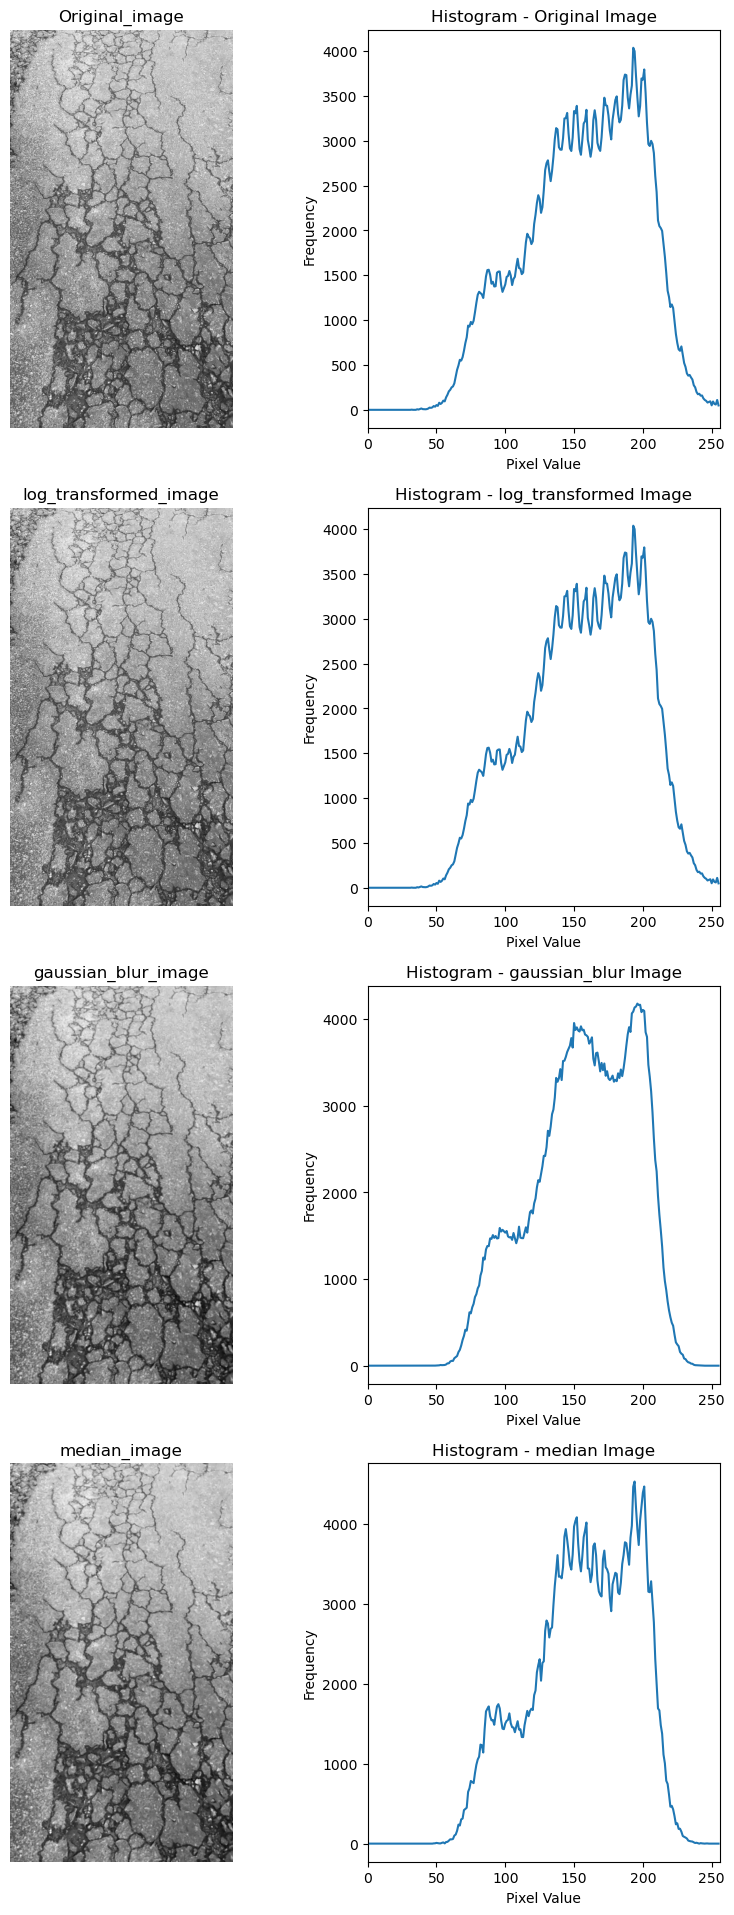

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def plot_histogram(image, title):
    """Plot histogram of the given image."""
    histogram = cv2.calcHist([image], [0], None,[256], [0, 256])
    
    plt.title(title)
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.plot(histogram)
    plt.xlim([0, 256])

def apply_log_transformed(image):
    image2 = image.astype(np.float32)

    r_max = np.max(image2)
    
    if r_max > 0:
        c = 255 / np.log(1 + r_max)
        log_transformed = np.array(image2)
    else:
        print("Maximum pixel value is 0, using the original image for display.")
        log_transformed = image
        
    return log_transformed
    
kernel_size = (3, 3) 
median_kernel = 3 
    
input_folder = "Frames"
output_folder = "Result"

image_path = input_folder + "/frame_0.jpg"
image = cv2.imread(image_path)

if image is None:
    print("Image not found!")

else:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    log_transformed = apply_log_transformed(gray)
    gaussian_blur = cv2.GaussianBlur(gray, kernel_size, 0)
    median = cv2.medianBlur(gray, median_kernel)
    
    plt.figure(figsize=(10,30))

    plt.subplot(5,2,1)
    plt.imshow(gray,cmap='gray')
    plt.axis("off")
    plt.title("Original_image")
    
    plt.subplot(5,2,2)
    plot_histogram(gray, "Histogram - Original Image")
    
    plt.subplot(5,2,3)
    plt.imshow(log_transformed,cmap='gray')
    plt.axis("off")
    plt.title("log_transformed_image")
    
    plt.subplot(5,2,4)
    plot_histogram(log_transformed, "Histogram - log_transformed Image")

    plt.subplot(5,2,5)
    plt.imshow(gaussian_blur,cmap='gray')
    plt.axis("off")
    plt.title("gaussian_blur_image")
    
    plt.subplot(5,2,6)
    plot_histogram(gaussian_blur, "Histogram - gaussian_blur Image")

    plt.subplot(5,2,7)
    plt.imshow(median,cmap='gray')
    plt.axis("off")
    plt.title("median_image")
    
    plt.subplot(5,2,8)
    plot_histogram(median, "Histogram - median Image")

    plt.show()
    cv2.imwrite(output_folder + "/original_gray.jpg", gray)
    cv2.imwrite(output_folder + "/gaussian_blur.jpg", gaussian_blur)
    cv2.imwrite(output_folder + "/log_transformed_gray.jpg", log_transformed)
        